Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pathlib 

In [2]:
df = pd.read_csv("sentiment_sentence_level_enriched.csv")

In [3]:
df.head()

,artist,title,disorder,sentence_index,sentence,model,raw_output,valence,arousal,dominance
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,0,Highest To Lowest: Quadeca LyricsQuadeca's Son...,VAD,"[{'label': 'LABEL_1', 'score': 3.3642196655273...",0.143427,0.182110,0.049787
1,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,1,"(20,121,625)\n- BEAMIN' (8,999,725)\n- War!",VAD,"[{'label': 'LABEL_1', 'score': 3.6385209560394...",0.114133,0.319260,0.127583
2,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,2,(feat.,VAD,"[{'label': 'LABEL_2', 'score': 3.1772220134735...",0.065396,0.059895,0.088611
3,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,3,"Dax) (8,850,668)\n- Wii Music Fire (7,069,076)...",VAD,"[{'label': 'LABEL_1', 'score': 3.1627085208892...",-0.001970,0.081354,0.067098
4,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,4,"B. Lou) (6,183,298)\n- WHERE'D YOU GO?",VAD,"[{'label': 'LABEL_2', 'score': 3.0688900947570...",0.015637,-0.030077,0.034445


In [26]:
# compute mean arousal, and means valence per disorder
mean_arousal_control = df[df['disorder'] == 'control']['arousal'].mean()
mean_valence_control = df[df['disorder'] == 'control']['valence'].mean()

mean_arousal_depression = df[df['disorder'] == 'depression']['arousal'].mean()
mean_valence_depression = df[df['disorder'] == 'depression']['valence'].mean()

print('control arousal:',mean_arousal_control)
print('control valence:',mean_valence_control)
print('step')
print('depression arousal:',mean_arousal_depression)
print('depression valence:',mean_valence_depression)

control arousal: 0.09181283997126012
control valence: -0.003489987819744927
step
depression arousal: 0.08114568117867596
depression valence: -0.00138021644884636


# One song plots

Two lines plot

In [4]:
def plot_song_va_path(
    df,
    song_id=None,
    song_title=None,
    id_col='song_id',
    title_col='title'
):

    if song_title is not None:
        if title_col not in df.columns:
            raise ValueError(f"Column '{title_col}' not found in dataframe.")
        song_df = df[df[title_col] == song_title].copy()

    elif song_id is not None:
        if id_col in df.columns:
            song_df = df[df[id_col] == song_id].copy()

        elif title_col in df.columns and np.issubdtype(type(song_id), np.integer):
            unique_titles = df[title_col].dropna().unique()

            if len(unique_titles) == 0:
                raise ValueError(f"No values found in '{title_col}' column.")

            if 1 <= int(song_id) <= len(unique_titles):
                resolved_title = unique_titles[int(song_id) - 1]
                song_df = df[df[title_col] == resolved_title].copy()
            else:
                raise ValueError(
                    f"No '{id_col}' column exists, and song_id={song_id} "
                    f"is out of range 1..{len(unique_titles)}."
                )
        else:
            raise ValueError(
                f"Column '{id_col}' not found. Use song_title='...' or pass a "
                f"1-based integer song_id to index '{title_col}'."
            )
    else:
        raise ValueError("Please provide song_id or song_title.")

    if song_df.empty:
        raise ValueError("No rows found for the selected song.")

    if 'sentence_index' not in song_df.columns:
        raise ValueError("Column 'sentence_index' not found in dataframe.")

    song_df = song_df.sort_values('sentence_index').reset_index(drop=True)
    x = song_df['sentence_index'].to_numpy()

    fig, ax = plt.subplots(figsize=(max(10, len(x) * 0.4), 5))

    ax.plot(
        x,
        song_df['valence'],
        marker='o',
        label='Valence',
        color='steelblue',
        linewidth=2
    )

    ax.plot(
        x,
        song_df['arousal'],
        marker='s',
        label='Arousal',
        color='tomato',
        linewidth=2
    )

    if 'dominance' in song_df.columns:
        ax.plot(
            x,
            song_df['dominance'],
            marker='^',
            label='Dominance',
            color='seagreen',
            linewidth=2,
            linestyle='--'
        )

    ax.axhline(0, linestyle='--', color='gray', alpha=0.4, linewidth=1)

    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    ax.set_ylim(-1.1, 1.1)

    ax.set_xlabel('Sentence index', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)

    ax.set_xticks(x)
    ax.tick_params(axis='x', labelsize=8)

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    if title_col in song_df.columns:
        title = song_df[title_col].iloc[0]
        ax.set_title(f'Sentence-level VA timeline: {title}', fontsize=13)
    else:
        ax.set_title('Sentence-level VA timeline', fontsize=13)

    plt.tight_layout()
    plt.show()


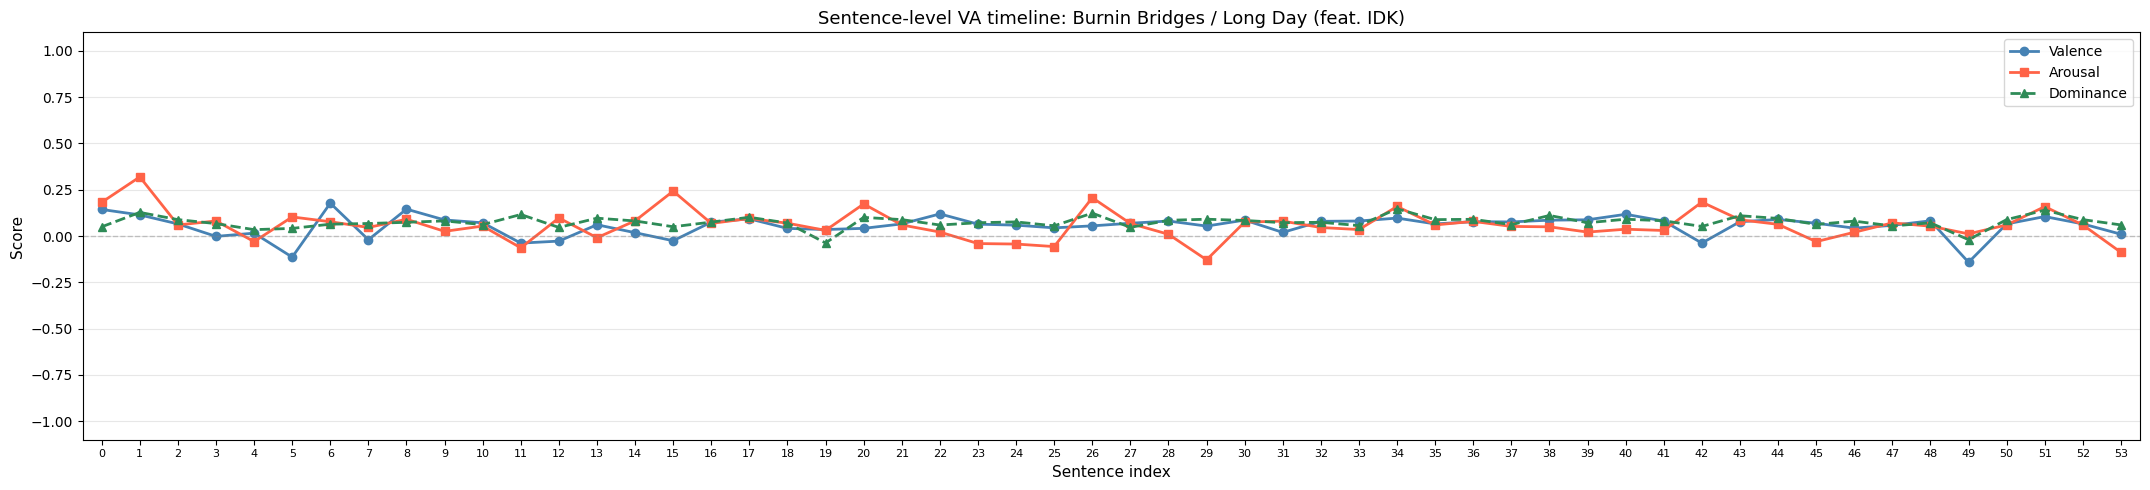

In [5]:
plot_song_va_path(df, song_id=1)

Spiral plot

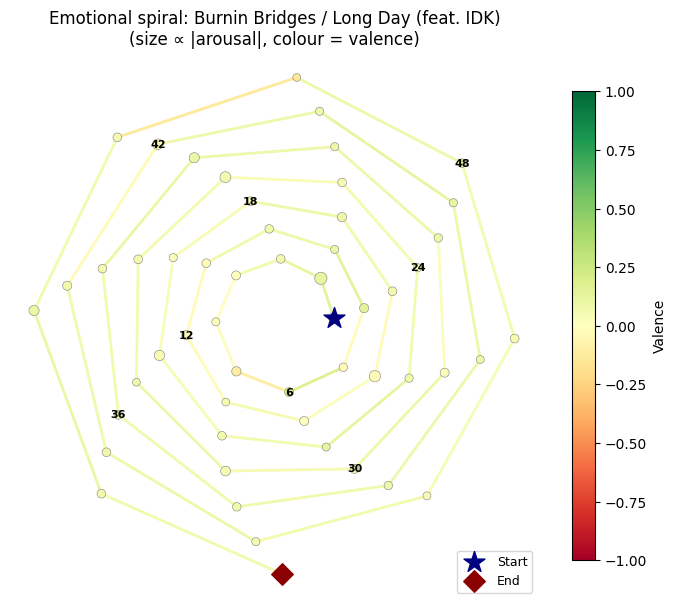

In [6]:
from matplotlib.collections import LineCollection


def plot_song_spiral(
    df,
    song_id=None,
    song_title=None,
    id_col='song_id',
    title_col='title'
):
    if song_title is not None:
        song_df = df[df[title_col] == song_title].copy()

    elif song_id is not None:
        if id_col in df.columns:
            song_df = df[df[id_col] == song_id].copy()
        else:
            unique_titles = df[title_col].dropna().unique()
            if 1 <= int(song_id) <= len(unique_titles):
                song_df = df[df[title_col] == unique_titles[int(song_id) - 1]].copy()
            else:
                raise ValueError(f"song_id={song_id} out of range 1..{len(unique_titles)}.")
    else:
        raise ValueError("Provide song_id or song_title.")

    if song_df.empty:
        raise ValueError("No rows found.")

    song_df = song_df.sort_values('sentence_index').reset_index(drop=True)

    n = len(song_df)
    n_turns = max(2, n / 8)

    theta = np.linspace(0, n_turns * 2 * np.pi, n)
    r = np.linspace(0.2, 1.0, n)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    valence = song_df['valence'].to_numpy()
    arousal = song_df['arousal'].to_numpy()

    norm = plt.Normalize(-1, 1)

    fig, ax = plt.subplots(figsize=(7, 7))

    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    lc = LineCollection(
        segs,
        cmap='RdYlGn',
        norm=norm,
        linewidth=2,
        zorder=2
    )
    lc.set_array(valence[:-1])

    ax.add_collection(lc)

    plt.colorbar(lc, ax=ax, label='Valence', shrink=0.7)

    sizes = np.abs(arousal) * 150 + 30

    ax.scatter(
        x,
        y,
        c=valence,
        cmap='RdYlGn',
        norm=norm,
        s=sizes,
        zorder=3,
        edgecolors='gray',
        linewidths=0.4
    )

    step = max(1, n // 8)

    for i in range(0, n, step):
        ax.annotate(
            str(int(song_df['sentence_index'].iloc[i])),
            (x[i], y[i]),
            fontsize=8,
            ha='center',
            va='center',
            fontweight='bold',
            color='black'
        )

    ax.scatter([x[0]], [y[0]], marker='*', s=250, color='navy', zorder=5, label='Start')
    ax.scatter([x[-1]], [y[-1]], marker='D', s=120, color='darkred', zorder=5, label='End')

    ax.legend(fontsize=9, loc='lower right')

    ax.set_aspect('equal')
    ax.axis('off')

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    ax.set_title(
        f'Emotional spiral: {title}\n(size ∝ |arousal|, colour = valence)',
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


plot_song_spiral(df, song_id=1)

Rearrange the dataset for 3d, arrow and labeled path plots

In [7]:
from mpl_toolkits.mplot3d import Axes3D

def get_song(df, song_id=None, song_title=None, id_col='song_id', title_col='title'):
    if song_title is not None:
        song_df = df[df[title_col] == song_title].copy()
    elif song_id is not None:
        if id_col in df.columns:
            song_df = df[df[id_col] == song_id].copy()
        else:
            unique_titles = df[title_col].dropna().unique()
            if 1 <= int(song_id) <= len(unique_titles):
                song_df = df[df[title_col] == unique_titles[int(song_id) - 1]].copy()
            else:
                raise ValueError(f"song_id={song_id} out of range 1..{len(unique_titles)}.")
    else:
        raise ValueError("Provide song_id or song_title.")

    if song_df.empty:
        raise ValueError("No rows found.")
    
    if 'sentence_index' not in song_df.columns:
        raise ValueError("Column 'sentence_index' not found in dataframe.")

    if 'valence' not in song_df.columns or 'arousal' not in song_df.columns:
        raise ValueError("Columns 'valence' and 'arousal' must be present in dataframe.")
    
    song_df = song_df.sort_values('sentence_index').reset_index(drop=True)
    
    return song_df

3D plot

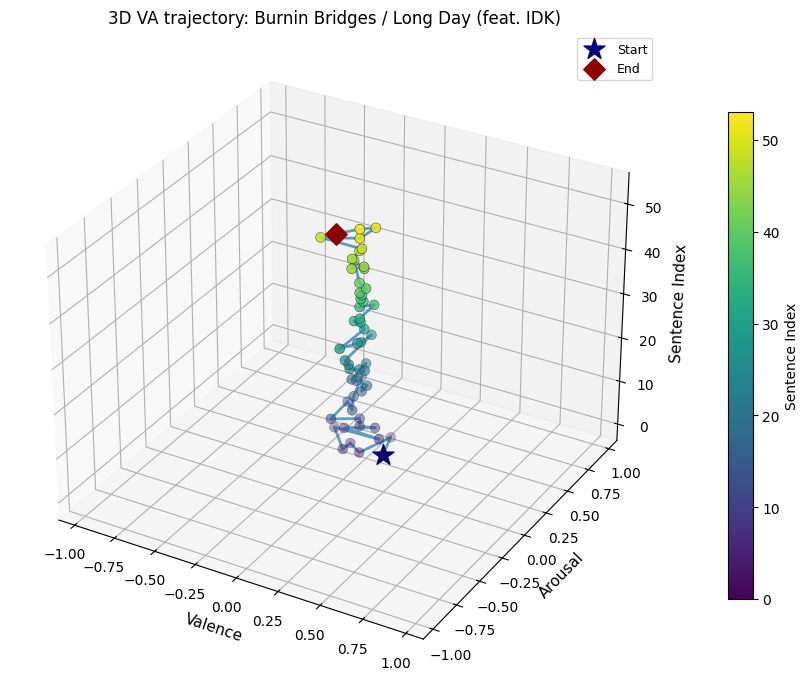

In [8]:
def plot_song_3d(df, song_id=None, song_title=None, id_col='song_id', title_col='title'):
    
    song_df = get_song(df, song_id=song_id, song_title=song_title, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    z = song_df['sentence_index'].to_numpy()

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(x, y, z, linewidth=2, alpha=0.7)
    sc = ax.scatter(x, y, z, c=z, cmap='viridis', s=50, edgecolors='black', linewidths=0.3)

    ax.scatter([x[0]], [y[0]], [z[0]], marker='*', s=250, color='navy', label='Start')
    ax.scatter([x[-1]], [y[-1]], [z[-1]], marker='D', s=120, color='darkred', label='End')

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

    ax.set_xlabel('Valence', fontsize=11)
    ax.set_ylabel('Arousal', fontsize=11)
    ax.set_zlabel('Sentence Index', fontsize=11)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)
    ax.set_title(f'3D VA trajectory: {title}', fontsize=12)

    fig.colorbar(sc, ax=ax, pad=0.08, shrink=0.75, label='Sentence Index')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

plot_song_3d(df, song_id=1)

Arrow plot

In [9]:
def plot_song_arrow(df, song_id=None, song_title=None, id_col='song_id', title_col='title'):
    song_df = get_song(df, song_id=song_id, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    n = len(song_df)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(x, y, alpha=0.35, linewidth=1.5)

    dx = np.diff(x)
    dy = np.diff(y)

    ax.quiver(
        x[:-1],
        y[:-1],
        dx,
        dy,
        np.arange(n - 1),
        cmap='viridis',
        angles='xy',
        scale_units='xy',
        scale=1,
        width=0.004,
        alpha=0.9
    )

    ax.scatter(x, y, cmap='viridis', s=25, zorder=3, edgecolors='black', linewidths=0.4)
    ax.scatter([x[0]], [y[0]], marker='*', s=250, color='navy', zorder=5, label='Start')
    ax.scatter([x[-1]], [y[-1]], marker='D', s=120, color='darkred', zorder=5, label='End')

    step = max(1, n // 8)
    for i in range(0, n, step):
        ax.annotate(
            str(int(song_df['sentence_index'].iloc[i])),
            (x[i], y[i]),
            fontsize=8,
            xytext=(4, 4),
            textcoords='offset points'
        )

    ax.axhline(0, linestyle='--', color='gray', alpha=0.4)
    ax.axvline(0, linestyle='--', color='gray', alpha=0.4)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel('Valence', fontsize=11)
    ax.set_ylabel('Arousal', fontsize=11)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)
    ax.set_title(f'VA trajectory with arrows: {title}', fontsize=12)

    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3574086/692340563.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, cmap='viridis', s=25, zorder=3, edgecolors='black', linewidths=0.4)


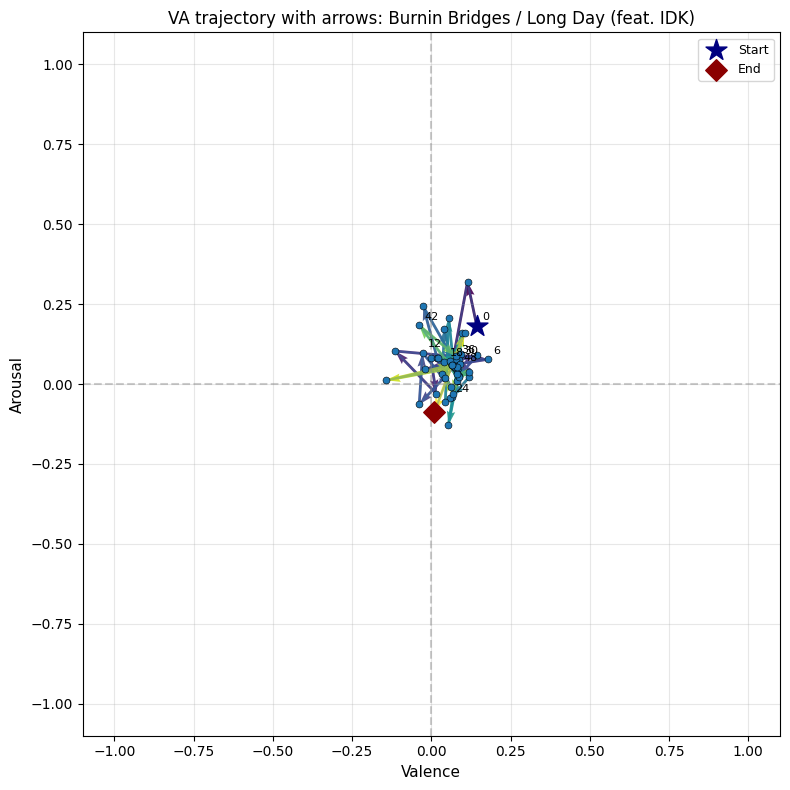

In [10]:
plot_song_arrow(df, song_id=1)

Cumulative VA plot

In [11]:
import os

def cumulative_va_path(df, song_id=None, song_title=None, id_col='song_id', title_col='title', save_frames=False, output_dir='frames_va_path', show=True):
    song_df = get_song(df, song_id=song_id, song_title=song_title, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    sidx = song_df['sentence_index'].to_numpy()
    n = len(song_df)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    if save_frames:
        os.makedirs(output_dir, exist_ok=True)

    for i in range(1, n + 1):
        fig, ax = plt.subplots(figsize=(8, 8))

        xi = x[:i]
        yi = y[:i]

        if i > 1:
            ax.plot(xi, yi, linewidth=2, alpha=0.7)

        ax.scatter(xi, yi, c=np.arange(i), cmap='viridis', s=70, zorder=3, edgecolors='black', linewidth=0.4)

        ax.scatter(xi[0], yi[0], marker='*', s=250, color='navy', zorder=5, label='Start')
        ax.scatter(xi[-1], yi[-1], marker='D', s=120, color='darkred', zorder=5, label='Current')

        for j in range(i):
            ax.annotate(
                str(int(sidx[j])),
                (xi[j], yi[j]),
                fontsize=8,
                xytext=(4, 4),
                textcoords='offset points'
            )

        ax.axhline(0, linestyle='--', color='gray', alpha=0.4)
        ax.axvline(0, linestyle='--', color='gray', alpha=0.4)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xlabel('Valence', fontsize=11)
        ax.set_ylabel('Arousal', fontsize=11)
        ax.set_title(f'Cumulative VA path: {title}\nStep {i}/{n}', fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        plt.tight_layout()

        if save_frames:
            fig.savefig(os.path.join(output_dir, f'frame_{i:03d}.png'), dpi=150, bbox_inches='tight')

        if show:
            plt.show()
        else:
            plt.close()

Cumulative spiral VA plot

In [12]:
def cumulative_spiral(
    df,
    song_id=None,
    song_title=None,
    id_col='song_id',
    title_col='title',
    save_frames=False,
    output_dir='frames_cumulative_spiral',
    show=True
):
    song_df = get_song(
        df,
        song_id=song_id,
        song_title=song_title,
        id_col=id_col,
        title_col=title_col
    )

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    sidx = song_df['sentence_index'].to_numpy()
    n = len(song_df)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    n_turns = max(2.5, n / 7)
    theta = np.linspace(0, n_turns * 2 * np.pi, n)
    r = np.linspace(0.2, 1.0, n)
    spiral_x = r * np.cos(theta)
    spiral_y = r * np.sin(theta)
    label_step = max(1, n // 8)

    if save_frames:
        os.makedirs(output_dir, exist_ok=True)

    for i in range(1, n + 1):
        fig, ax = plt.subplots(figsize=(7, 7))

        if i > 1:
            ax.plot(spiral_x[:i], spiral_y[:i], color='lightgray', linewidth=1.5)

        sc = ax.scatter(
            spiral_x[:i],
            spiral_y[:i],
            c=x[:i],
            cmap='RdYlGn',
            norm=plt.Normalize(-1, 1),
            s=np.abs(y[:i]) * 150 + 30,
            edgecolors='gray',
            linewidths=0.4,
            zorder=3
        )

        ax.scatter(
            spiral_x[0],
            spiral_y[0],
            marker='*',
            s=250,
            color='navy',
            zorder=5,
            label='Start'
        )
        ax.scatter(
            spiral_x[i - 1],
            spiral_y[i - 1],
            marker='D',
            s=120,
            color='darkred',
            zorder=5,
            label='Current'
        )

        for j in range(0, i, label_step):
            ax.annotate(
                str(int(sidx[j])),
                (spiral_x[j], spiral_y[j]),
                fontsize=8,
                ha='center',
                va='center',
                color='#222222',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.65)
            )

        if (i - 1) % label_step != 0:
            ax.annotate(
                str(int(sidx[i - 1])),
                (spiral_x[i - 1], spiral_y[i - 1]),
                fontsize=8,
                ha='center',
                va='center',
                color='#222222',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75)
            )

        cbar = fig.colorbar(sc, ax=ax, shrink=0.72, pad=0.01)
        cbar.set_label('Valence', fontsize=10)

        ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(
            f'Cumulative emotional spiral: {title}\nStep {i}/{n}  |  size ∝ |arousal|, color = valence',
            fontsize=12,
            pad=14
        )
        plt.tight_layout()

        if save_frames:
            fig.savefig(
                os.path.join(output_dir, f'frame_{i:03d}.png'),
                dpi=170,
                bbox_inches='tight'
            )

        if show:
            plt.show()
        else:
            plt.close(fig)

Cumulative 3D plot

In [13]:
def cumulative_3d_path(df, song_id=None, song_title=None, id_col='song_id', title_col='title', save_frames=False, output_dir='frames_cumulative_3d', show=True):
    song_df = get_song(df, song_id=song_id, song_title=song_title, id_col=id_col, title_col=title_col)

    x = song_df['valence'].to_numpy()
    y = song_df['arousal'].to_numpy()
    z = song_df['sentence_index'].to_numpy()
    n = len(song_df)

    title = song_df[title_col].iloc[0] if title_col in song_df.columns else str(song_id or song_title)

    if save_frames:
        os.makedirs(output_dir, exist_ok=True)

    for i in range(1, n + 1):
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')

        xi = x[:i]
        yi = y[:i]
        zi = z[:i]

        if i > 1:
            ax.plot(xi, yi, zi, linewidth=2, alpha=0.7)

        sc = ax.scatter(xi, yi, zi, c=zi, cmap='viridis', s=50, edgecolors='black', linewidths=0.3)

        ax.scatter([xi[0]], [yi[0]], [zi[0]], marker='*', s=250, color='navy', label='Start')
        ax.scatter([xi[-1]], [yi[-1]], [zi[-1]], marker='D', s=120, color='darkred', label='Current')

        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xlabel('Valence', fontsize=11)
        ax.set_ylabel('Arousal', fontsize=11)
        ax.set_zlabel('Sentence Index', fontsize=11)
        ax.set_title(f'Cumulative 3D VA path: {title}\nStep {i}/{n}', fontsize=12)
        fig.colorbar(sc, ax=ax, pad=0.08, shrink=0.75, label='Sentence Index')
        ax.legend(fontsize=9)

        plt.tight_layout()

        if save_frames:
            fig.savefig(os.path.join(output_dir, f'frame_{i:03d}.png'), dpi=150, bbox_inches='tight')

        if show:
            plt.show()
        else:
            plt.close(fig)

Make videos

In [14]:
import imageio.v2 as imageio
from PIL import Image

def make_video(frames_dir, output_path='animation.mp4', fps=10):
    files = sorted([
        f for f in os.listdir(frames_dir)
        if f.endswith('.png')
    ])

    if not files:
        raise ValueError(f'No PNG frames found in {frames_dir}.')

    first_frame = Image.open(os.path.join(frames_dir, files[0])).convert('RGB')
    frame_size = first_frame.size

    with imageio.get_writer(output_path, mode='I', fps=fps) as writer:
        for f in files:
            path = os.path.join(frames_dir, f)
            image = Image.open(path).convert('RGB')
            if image.size != frame_size:
                image = image.resize(frame_size, Image.Resampling.LANCZOS)
            writer.append_data(np.asarray(image))

In [15]:
cumulative_spiral(df, song_id=1, show=False, save_frames=True, output_dir='spiral_frames')

make_video('spiral_frames', output_path='animation.mp4', fps=10)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (975, 1168) to (976, 1168) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


# Trajectories

Feature extraction

In [16]:
def extract_trajectory_features(df, group_cols=('artist', 'title')):
    features = []

    for song_key, g in df.groupby(list(group_cols)):
        g = g.sort_values('sentence_index')

        v = g['valence'].to_numpy()
        a = g['arousal'].to_numpy()

        if len(v) < 2:
            continue

        dv = np.diff(v)
        da = np.diff(a)

        artist, title = song_key

        features.append({
            'artist': artist,
            'title': title,
            'mean_valence': np.mean(v),
            'std_valence': np.std(v),
            'mean_arousal': np.mean(a),
            'std_arousal': np.std(a),
            'valence_range': np.max(v) - np.min(v),
            'path_length': np.sum(np.sqrt(dv**2 + da**2)),
            'switches': np.sum(np.sign(v[:-1]) != np.sign(v[1:])),
            'neg_ratio': np.mean(v < 0),
            'slope': (v[-1] - v[0]) / len(v),
            'start_valence': v[0],
            'end_valence': v[-1],
            'delta_valence': v[-1] - v[0],
        })

    return pd.DataFrame(features)

features_df = extract_trajectory_features(df)

song_labels = df[['artist', 'title', 'disorder']].drop_duplicates()

full_df = features_df.merge(song_labels, on=['artist', 'title'], how='left')

def compare_features(df, feature, label_col='disorder'):
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=label_col, y=feature)
    sns.stripplot(data=df, x=label_col, y=feature, alpha=0.3)
    plt.title(feature)
    plt.grid(alpha=0.3)
    plt.show()

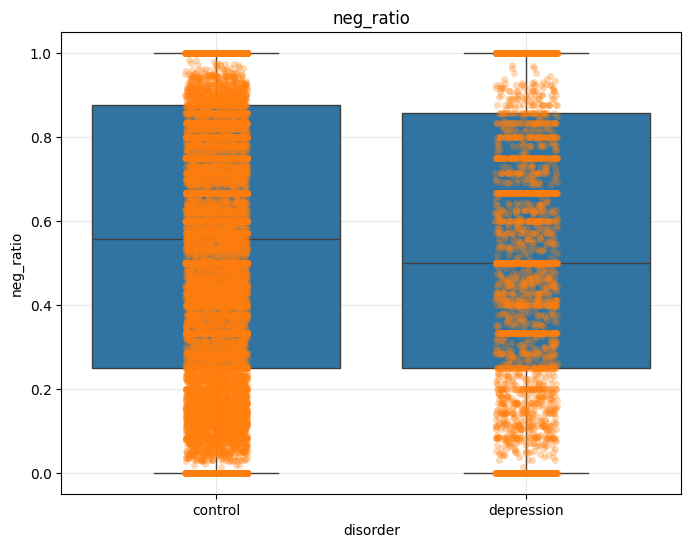

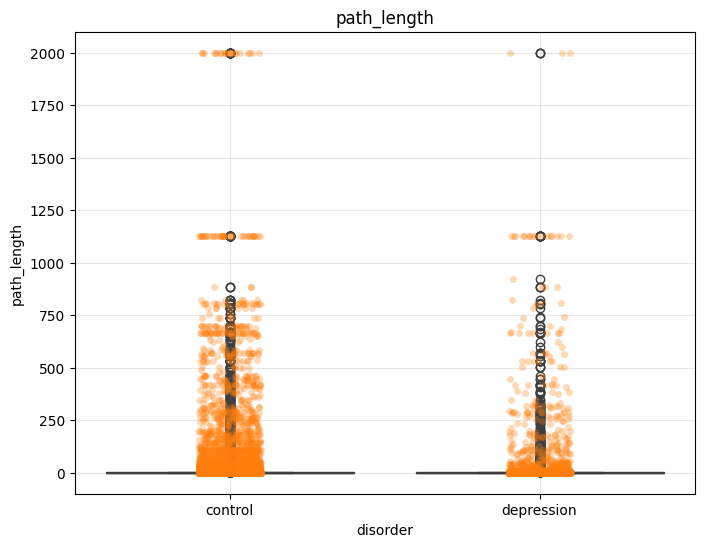

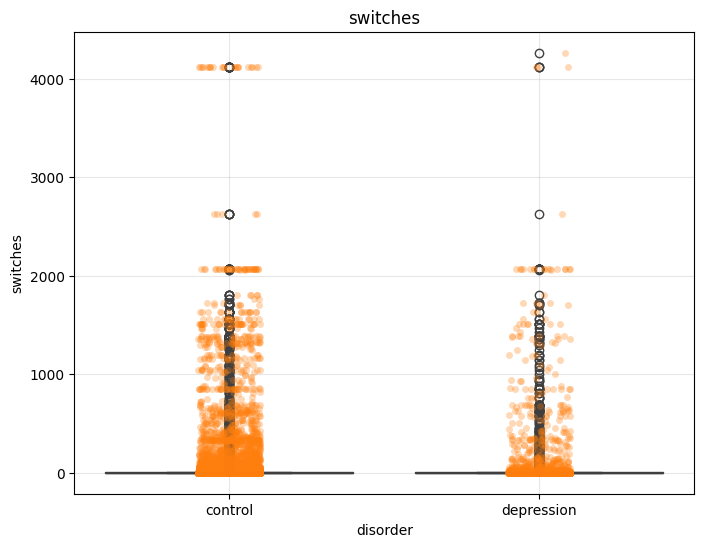

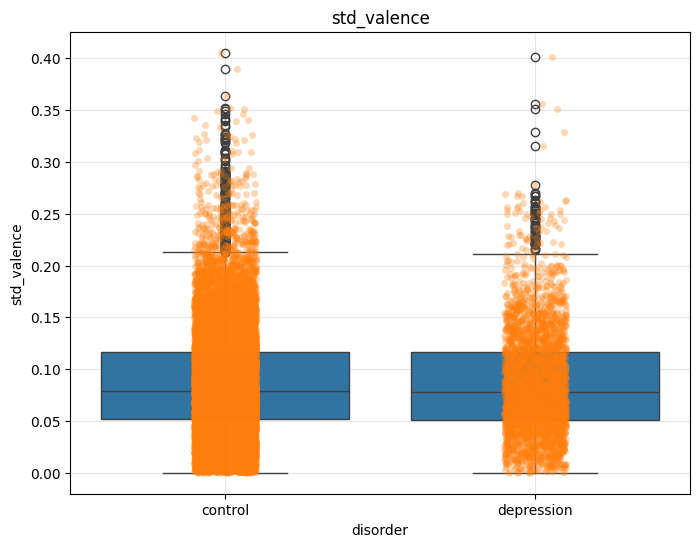

In [17]:
compare_features(full_df, 'neg_ratio')
compare_features(full_df, 'path_length')
compare_features(full_df, 'switches')
compare_features(full_df, 'std_valence')

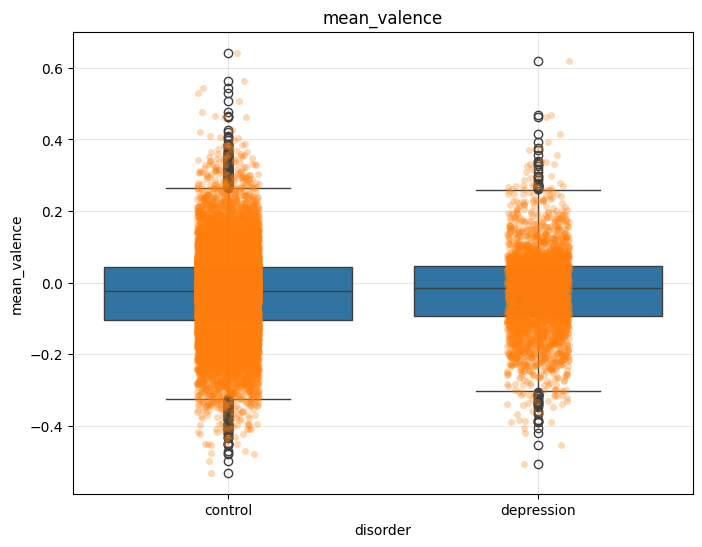

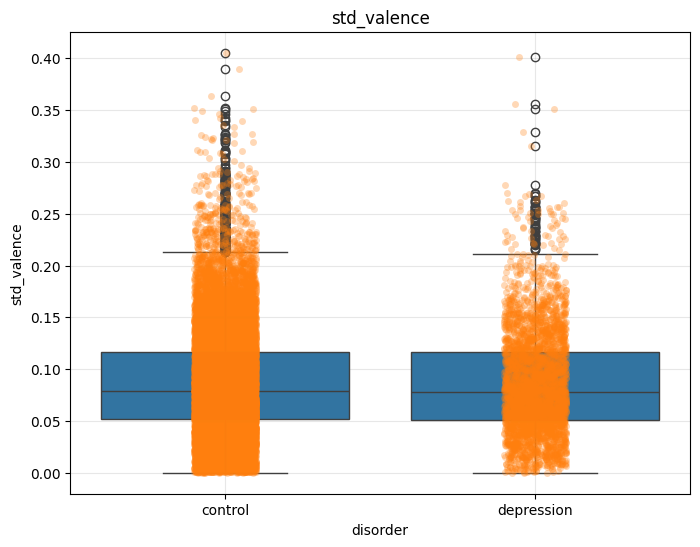

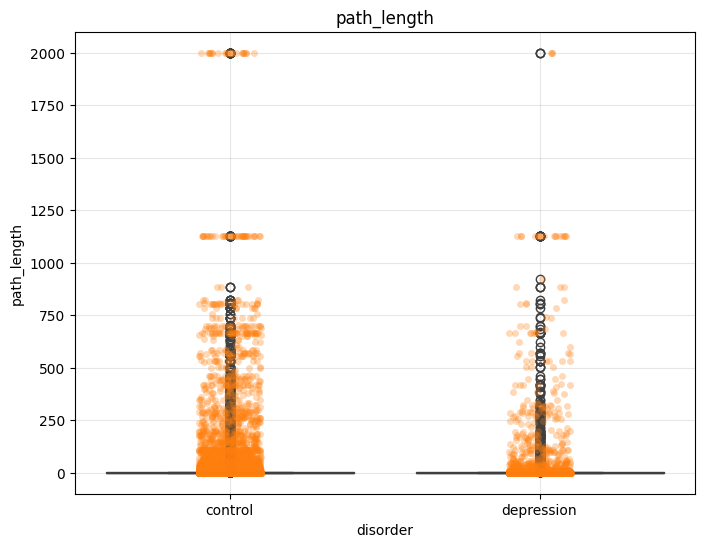

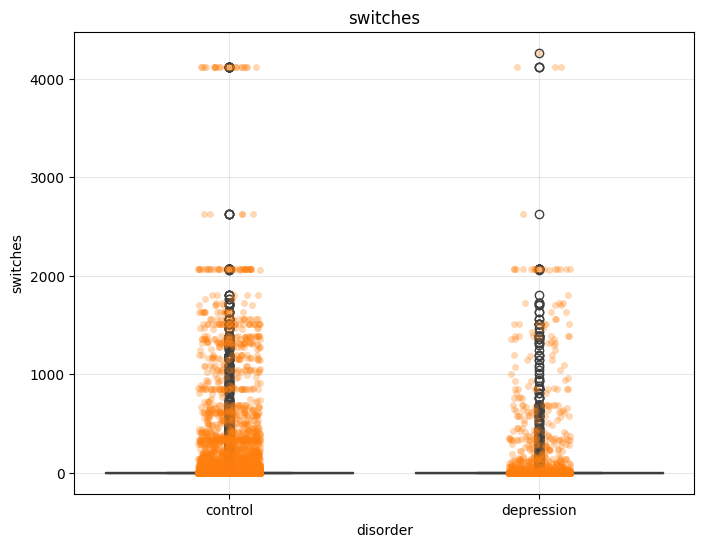

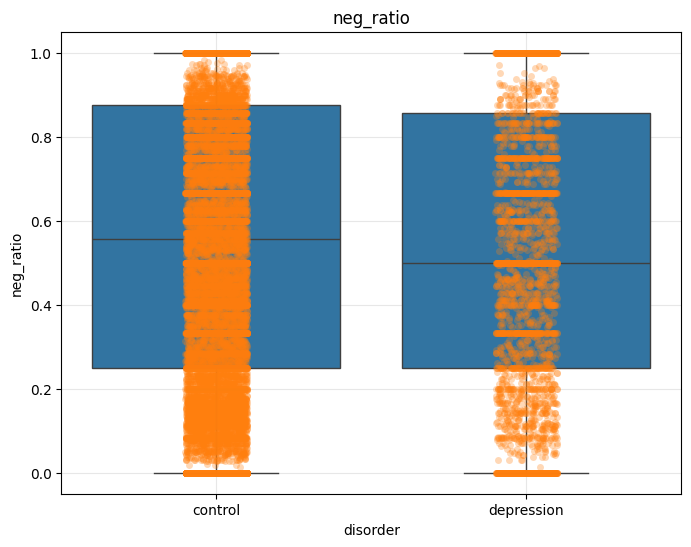

In [18]:
features_to_plot = [
    'mean_valence',
    'std_valence',
    'path_length',
    'switches',
    'neg_ratio'
]

for f in features_to_plot:
    compare_features(full_df, f)

In [19]:
def resample_trajectory(v, target_length=20):
    x_old = np.linspace(0, 1, len(v))
    x_new = np.linspace(0, 1, target_length)
    return np.interp(x_new, x_old, v)

## Balanced feature exploration

Resample the control and depression groups to the same number of songs, then plot the feature distributions and relationships across all extracted trajectory features.

disorder
control       3396
depression    3396
Name: count, dtype: int64
Using 12 numeric trajectory features.


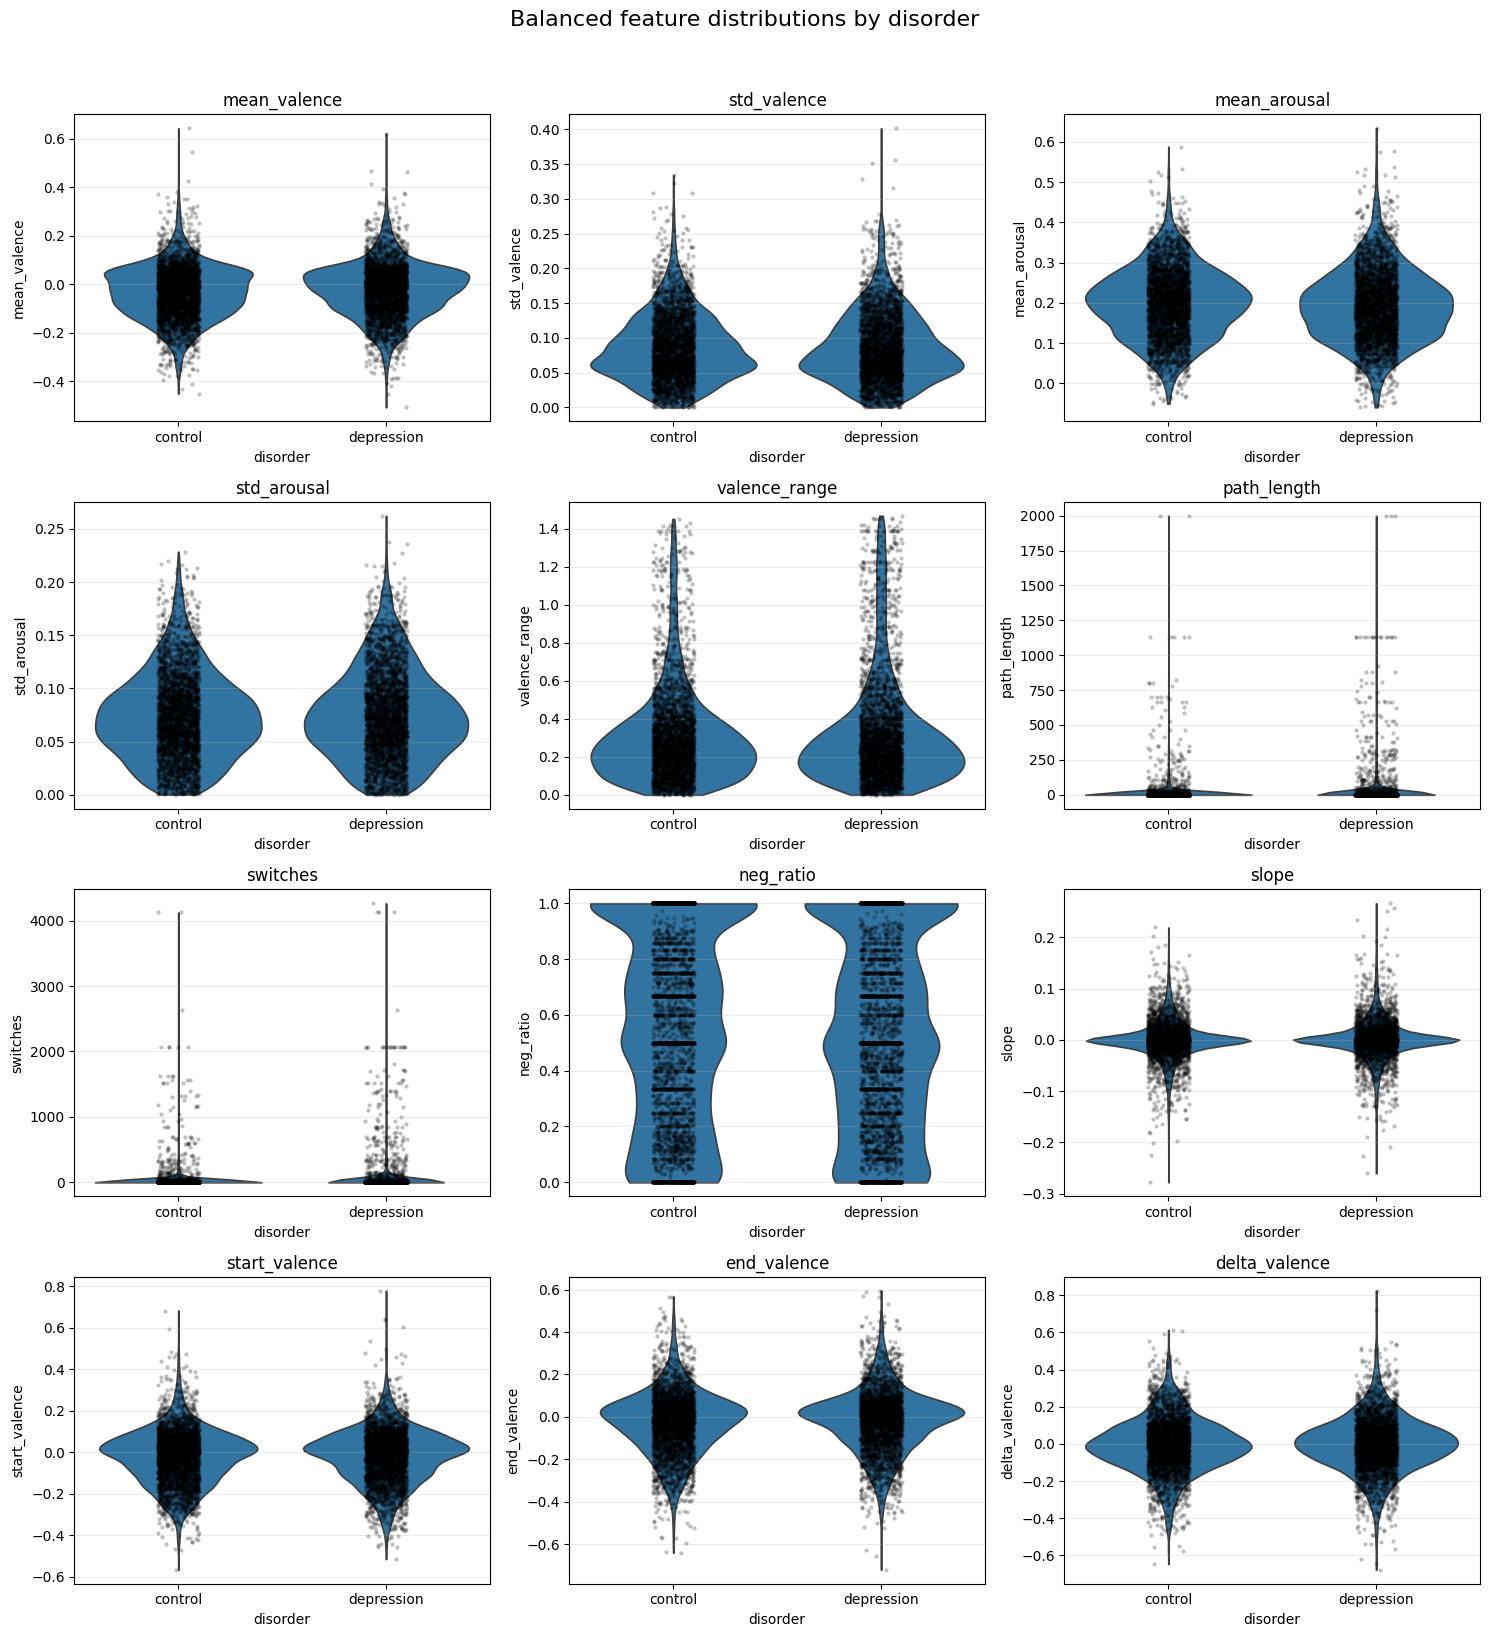

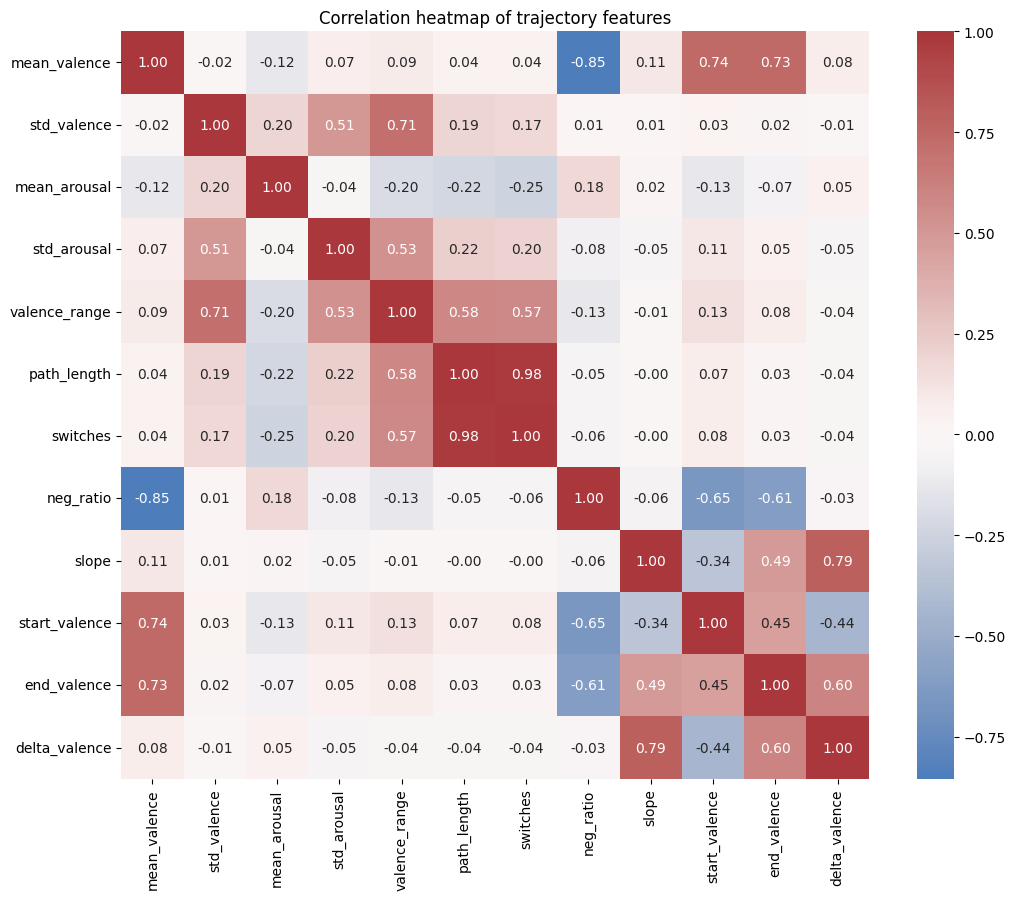

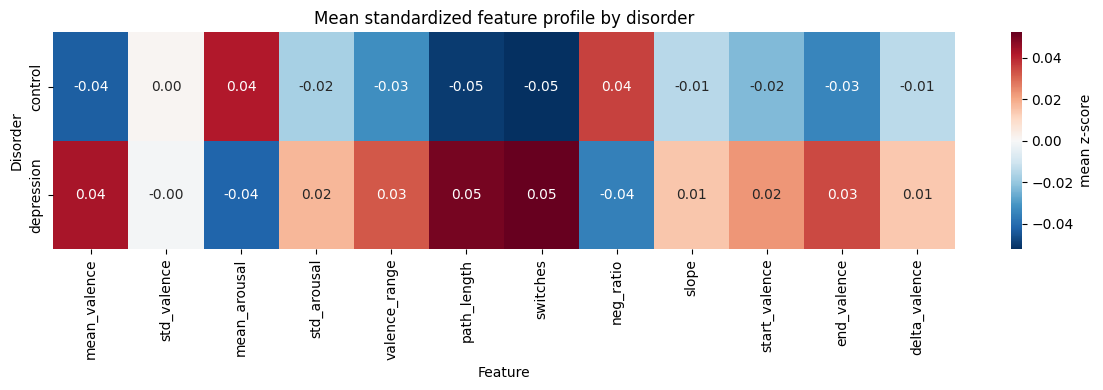

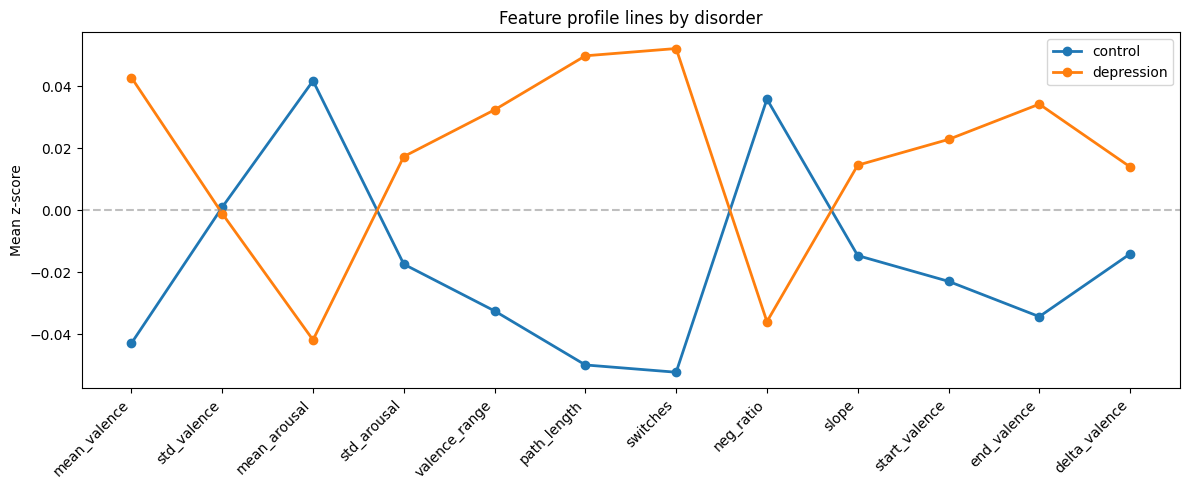

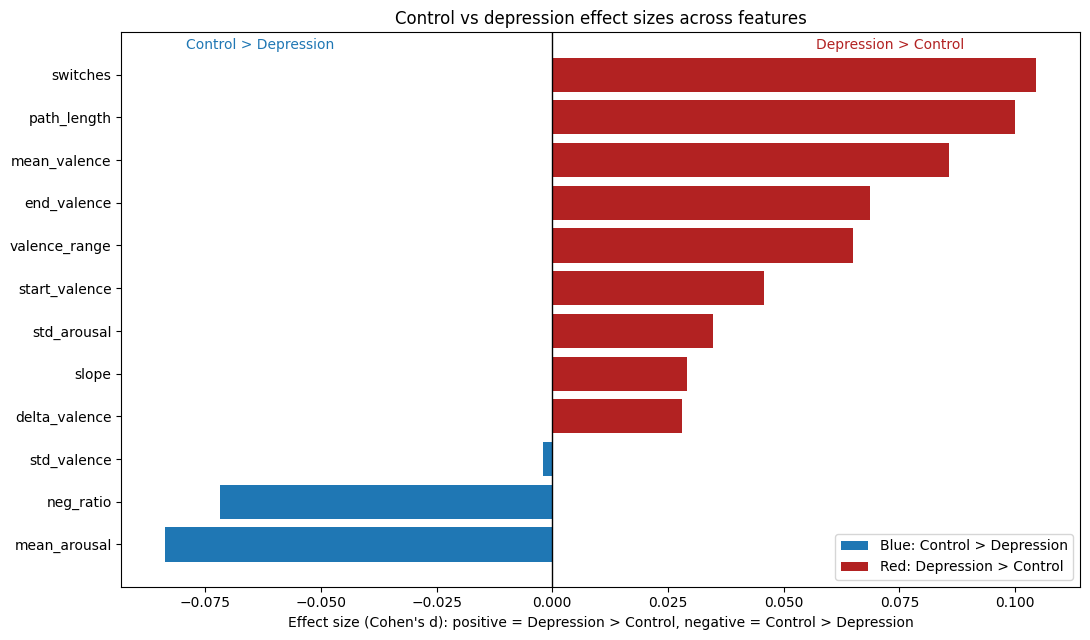

In [20]:
feature_columns = [
    col for col in full_df.columns
    if col not in {'artist', 'title', 'disorder'}
    and pd.api.types.is_numeric_dtype(full_df[col])
]


def balance_song_groups(df, label_col='disorder', target_labels=('control', 'depression'), random_state=42):
    work_df = df.copy()
    work_df['_label_norm'] = work_df[label_col].astype(str).str.strip().str.lower()

    selected_labels = [label for label in target_labels if label in set(work_df['_label_norm'])]
    if len(selected_labels) != 2:
        raise ValueError(
            f'Expected to find both {target_labels} in {label_col}, '
            f'but found {sorted(work_df[label_col].dropna().unique())}.'
        )

    subset = work_df[work_df['_label_norm'].isin(selected_labels)].copy()
    sample_size = subset['_label_norm'].value_counts().min()

    sampled_groups = []
    for label in selected_labels:
        group = subset[subset['_label_norm'] == label]
        sampled_groups.append(group.sample(sample_size, random_state=random_state))

    balanced = pd.concat(sampled_groups, ignore_index=True)
    balanced = balanced.drop(columns='_label_norm')
    balanced = balanced.sort_values([label_col, 'artist', 'title']).reset_index(drop=True)
    return balanced


balanced_df = balance_song_groups(full_df)
print(balanced_df['disorder'].value_counts())
print(f'Using {len(feature_columns)} numeric trajectory features.')


def plot_feature_grid(df, features, label_col='disorder', ncols=3):
    n_features = len(features)
    nrows = int(np.ceil(n_features / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, feature in zip(axes, features):
        sns.violinplot(data=df, x=label_col, y=feature, inner=None, cut=0, ax=ax)
        sns.stripplot(data=df, x=label_col, y=feature, color='black', alpha=0.25, size=3, ax=ax)
        ax.set_title(feature)
        ax.grid(axis='y', alpha=0.25)

    for ax in axes[n_features:]:
        ax.set_visible(False)

    fig.suptitle('Balanced feature distributions by disorder', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_correlation(df, features):
    corr = df[features].corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f', square=True)
    plt.title('Correlation heatmap of trajectory features')
    plt.tight_layout()
    plt.show()


def plot_disorder_feature_profiles(df, features, label_col='disorder'):
    standardized = df[features].apply(
        lambda col: (col - col.mean()) / col.std(ddof=0) if col.std(ddof=0) else pd.Series(0, index=col.index)
    )
    standardized[label_col] = df[label_col].values
    profile_df = standardized.groupby(label_col)[features].mean()

    plt.figure(figsize=(12, 4))
    sns.heatmap(profile_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f', cbar_kws={'label': 'mean z-score'})
    plt.title('Mean standardized feature profile by disorder')
    plt.xlabel('Feature')
    plt.ylabel('Disorder')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    for disorder, row in profile_df.iterrows():
        plt.plot(features, row.values, marker='o', linewidth=2, label=disorder)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Mean z-score')
    plt.title('Feature profile lines by disorder')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_effect_sizes(df, features, label_col='disorder', negative_label='control', positive_label='depression'):
    from matplotlib.patches import Patch

    grouped = {
        label.lower(): group[features]
        for label, group in df.groupby(df[label_col].astype(str).str.lower())
    }
    if negative_label not in grouped or positive_label not in grouped:
        raise ValueError(f'Expected {negative_label} and {positive_label} in {label_col}.')

    negative = grouped[negative_label]
    positive = grouped[positive_label]

    pooled_std = np.sqrt((negative.var(ddof=1) + positive.var(ddof=1)) / 2)
    effect_sizes = (positive.mean() - negative.mean()) / pooled_std.replace(0, np.nan)
    effect_sizes = effect_sizes.sort_values()

    values = effect_sizes.fillna(0)
    colors = ['#b22222' if value > 0 else '#1f77b4' for value in values]

    plt.figure(figsize=(11, 6.5))
    plt.barh(effect_sizes.index, values, color=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel("Effect size (Cohen's d): positive = Depression > Control, negative = Control > Depression")
    plt.title('Control vs depression effect sizes across features')

    xlim = plt.xlim()
    y_top = len(effect_sizes) - 0.4
    plt.text(xlim[0] * 0.85, y_top, 'Control > Depression', color='#1f77b4', fontsize=10, ha='left')
    plt.text(xlim[1] * 0.50, y_top, 'Depression > Control', color='#b22222', fontsize=10, ha='left')

    legend_items = [
        Patch(facecolor='#1f77b4', label='Blue: Control > Depression'),
        Patch(facecolor='#b22222', label='Red: Depression > Control')
    ]
    plt.legend(handles=legend_items, loc='lower right', frameon=True)

    plt.tight_layout()
    plt.show()


plot_feature_grid(balanced_df, feature_columns)
plot_feature_correlation(balanced_df, feature_columns)
plot_disorder_feature_profiles(balanced_df, feature_columns)
plot_effect_sizes(balanced_df, feature_columns)

## Some validation

Feature analysis:
- PCA and t-SNE projections
- Feature-wise statistical testing with FDR correction
- Cross-validated classification performance

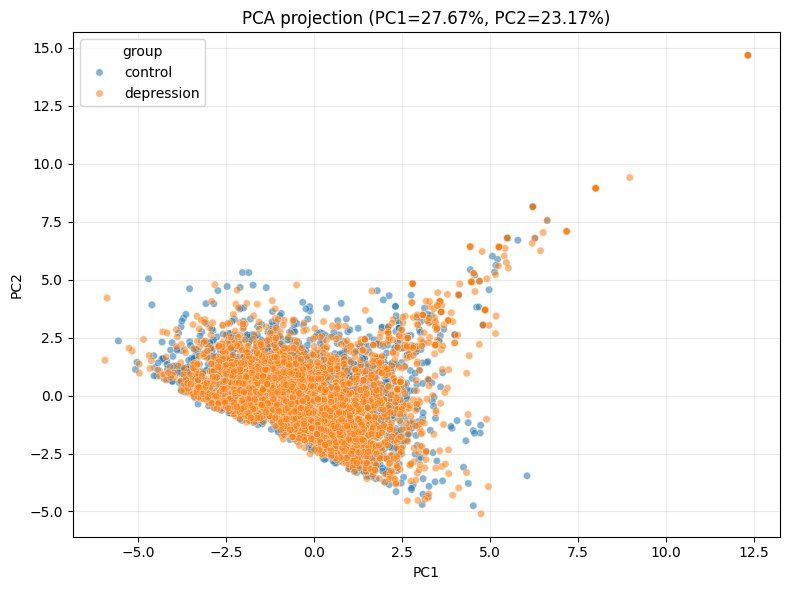

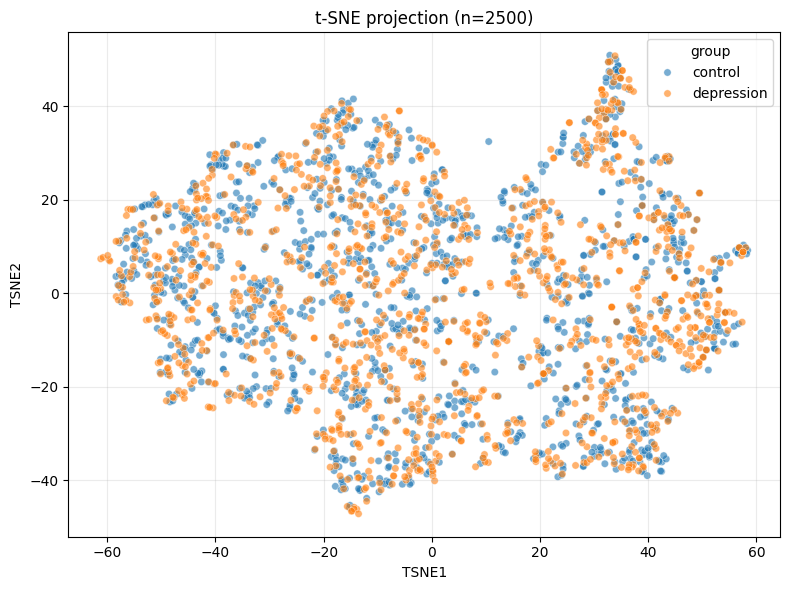

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Prepare balanced matrix and binary labels.
analysis_df = balanced_df.copy()
analysis_df['_label_norm'] = analysis_df['disorder'].astype(str).str.strip().str.lower()
analysis_df = analysis_df[analysis_df['_label_norm'].isin(['control', 'depression'])].copy()

X = analysis_df[feature_columns].to_numpy()
y = analysis_df['_label_norm'].map({'control': 0, 'depression': 1}).to_numpy()


def plot_pca_projection(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'group': np.where(y == 1, 'depression', 'control')
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', alpha=0.55, s=28)
    plt.title(
        f"PCA projection (PC1={pca.explained_variance_ratio_[0]:.2%}, "
        f"PC2={pca.explained_variance_ratio_[1]:.2%})"
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_tsne_projection(X, y, max_points=2500):
    rng = np.random.default_rng(42)

    if len(y) > max_points:
        idx_ctrl = np.where(y == 0)[0]
        idx_dep = np.where(y == 1)[0]
        per_class = max_points // 2

        take_ctrl = rng.choice(idx_ctrl, size=min(per_class, len(idx_ctrl)), replace=False)
        take_dep = rng.choice(idx_dep, size=min(per_class, len(idx_dep)), replace=False)
        keep = np.concatenate([take_ctrl, take_dep])
    else:
        keep = np.arange(len(y))

    X_sub = X[keep]
    y_sub = y[keep]

    X_sub = StandardScaler().fit_transform(X_sub)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_sub)

    tsne_df = pd.DataFrame({
        'TSNE1': X_tsne[:, 0],
        'TSNE2': X_tsne[:, 1],
        'group': np.where(y_sub == 1, 'depression', 'control')
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='group', alpha=0.6, s=28)
    plt.title(f't-SNE projection (n={len(tsne_df)})')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_pca_projection(X, y)
plot_tsne_projection(X, y)

Top features after BH-FDR correction:


,feature,mean_diff,cohen_d,p_value,p_fdr_bh
0,mean_arousal,-0.007331,-0.083694,0.000030,0.000358
1,mean_valence,0.009456,0.085787,0.000257,0.001540
2,neg_ratio,-0.024738,-0.071853,0.002058,0.008233
3,end_valence,0.010069,0.068605,0.009697,0.029090
4,start_valence,0.005972,0.045796,0.036323,0.087174
5,switches,25.116313,0.104598,0.056087,0.112174
6,slope,0.001095,0.029175,0.070827,0.121417
7,delta_valence,0.004097,0.028085,0.114339,0.171509
8,std_arousal,0.001436,0.034744,0.320754,0.427672
9,std_valence,-0.000101,-0.002057,0.551174,0.601281


Cross-validated classifier performance (balanced classes):


,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,RandomForest,0.535779,0.008466,0.534407,0.018783,0.552903,0.012006
1,SVM-RBF,0.523853,0.013672,0.508524,0.024423,0.540855,0.016637
0,LogisticRegression,0.517671,0.013139,0.517196,0.027633,0.524117,0.016713


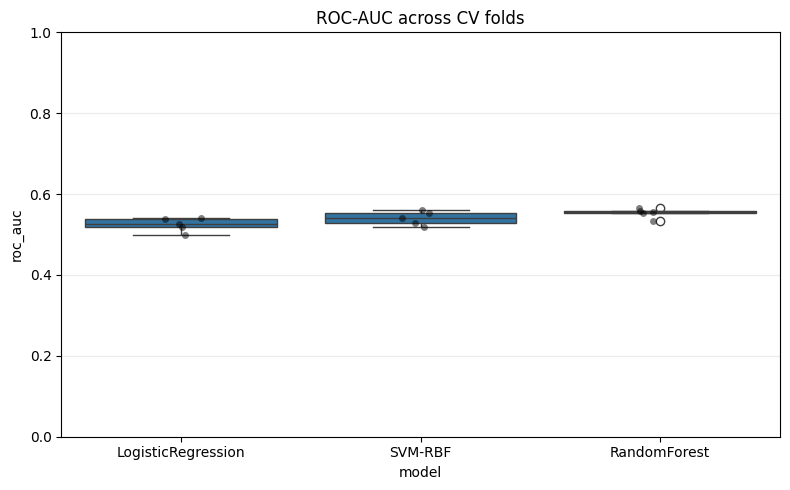

In [22]:
from scipy.stats import mannwhitneyu
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


def bh_fdr(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        value = ranked[i] * n / rank
        prev = min(prev, value)
        adjusted[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(adjusted, 0, 1)
    return out


def cohen_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)
    pooled = np.sqrt((vx + vy) / 2)
    if pooled == 0:
        return np.nan
    return (np.mean(y) - np.mean(x)) / pooled


control = analysis_df[analysis_df['_label_norm'] == 'control']
depression = analysis_df[analysis_df['_label_norm'] == 'depression']

stats_rows = []
for feature in feature_columns:
    x_ctrl = control[feature].to_numpy()
    x_dep = depression[feature].to_numpy()

    _, p_value = mannwhitneyu(x_ctrl, x_dep, alternative='two-sided')
    d_value = cohen_d(x_ctrl, x_dep)

    stats_rows.append({
        'feature': feature,
        'control_mean': np.mean(x_ctrl),
        'depression_mean': np.mean(x_dep),
        'mean_diff': np.mean(x_dep) - np.mean(x_ctrl),
        'cohen_d': d_value,
        'p_value': p_value,
    })

stats_df = pd.DataFrame(stats_rows)
stats_df['p_fdr_bh'] = bh_fdr(stats_df['p_value'].to_numpy())
stats_df = stats_df.sort_values('p_fdr_bh').reset_index(drop=True)

print('Top features after BH-FDR correction:')
display(stats_df[['feature', 'mean_diff', 'cohen_d', 'p_value', 'p_fdr_bh']].head(12))


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, random_state=42))
    ]),
    'SVM-RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, random_state=42))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = []
fold_rows = []
for model_name, model in models.items():
    cv_out = cross_validate(model, X, y, scoring=scoring, cv=cv, n_jobs=-1)

    results.append({
        'model': model_name,
        'accuracy_mean': cv_out['test_accuracy'].mean(),
        'accuracy_std': cv_out['test_accuracy'].std(ddof=1),
        'f1_mean': cv_out['test_f1'].mean(),
        'f1_std': cv_out['test_f1'].std(ddof=1),
        'roc_auc_mean': cv_out['test_roc_auc'].mean(),
        'roc_auc_std': cv_out['test_roc_auc'].std(ddof=1),
    })

    for fold_idx, score in enumerate(cv_out['test_roc_auc'], start=1):
        fold_rows.append({
            'model': model_name,
            'fold': fold_idx,
            'roc_auc': score
        })

results_df = pd.DataFrame(results).sort_values('roc_auc_mean', ascending=False)
print('Cross-validated classifier performance (balanced classes):')
display(results_df)

fold_df = pd.DataFrame(fold_rows)
plt.figure(figsize=(8, 5))
sns.boxplot(data=fold_df, x='model', y='roc_auc')
sns.stripplot(data=fold_df, x='model', y='roc_auc', color='black', alpha=0.5)
plt.ylim(0.0, 1.0)
plt.title('ROC-AUC across CV folds')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()